# Atividade 2: meta-características específicas do domínio

Mesmo meta-dataset da Atividade 1 (mesma P, mesmo R, mesmo protocolo); só muda X.
Recorte: desbalanceamento e dificuldade de classe.

As funções da Atividade 1 estão em `atividade1.py`, copiadas do notebook anterior por
`.build/extrair_atividade1.py`.

In [1]:
import time
import warnings
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import problexity as px
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

import atividade1 as a1

warnings.filterwarnings("ignore")

DADOS = Path("../dados_openml")
BASE = Path("base")

P = pd.read_csv(BASE / "matriz_performance.csv", index_col=["did", "nome"]).sort_index()
R = pd.read_csv(BASE / "matriz_ranks.csv", index_col=["did", "nome"]).sort_index()
V = pd.read_csv(BASE / "matriz_vitorias.csv", index_col=["did", "nome"]).sort_index()
X_base = pd.read_csv(BASE / "metadataset.csv", index_col=["did", "nome"]).sort_index()
assert list(X_base.index) == list(P.index) == list(R.index) == list(V.index)

ALGORITMOS = list(P.columns)
Pn, Rn, Vn = P.to_numpy(), R.to_numpy(), V.to_numpy()
n_datasets, n_algos = P.shape

DIVERGENTE = LinearSegmentedColormap.from_list("divergente", ["#9e3332", "#f0efec", "#1c5cab"])
SEQUENCIAL = LinearSegmentedColormap.from_list(
    "sequencial", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
plt.rcParams.update({
    "figure.facecolor": a1.SUPERFICIE, "axes.facecolor": a1.SUPERFICIE, "savefig.facecolor": a1.SUPERFICIE,
    "axes.edgecolor": a1.TINTA_2, "axes.labelcolor": a1.TINTA, "text.color": a1.TINTA,
    "xtick.color": a1.TINTA_2, "ytick.color": a1.TINTA_2, "grid.color": a1.GRADE, "grid.linewidth": 0.8,
    "axes.grid": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110,
})

print(P.shape, R.shape, X_base.shape)

(33, 6) (33, 6) (33, 32)


## 1. Levantamento

Quadro 1: o que entrou no X estendido. Quadro 2: o que ficou de fora.

In [2]:
quadro_levantamento = pd.DataFrame([
    {"meta-característica": "ImbalanceDegree",
     "família": "simples (distribuição de classes)",
     "referência": "Ortigosa-Hernández, Inza e Lozano (2017)",
     "definição": "(m − 1) + d(ζ, e) / d(ι_m, e): ζ proporções das classes, e distribuição uniforme, "
                  "m nº de classes abaixo de 1/K, ι_m a distribuição mais desigual com m minoritárias, "
                  "d a distância de Hellinger",
     "captura": "extensão do desbalanceamento multiclasse, contando quantas classes são minoritárias",
     "por que aqui": "18 dos 33 datasets são multiclasse; a razão majoritária/minoritária do X_base só "
                     "enxerga os dois extremos da distribuição",
     "custo": "O(n)", "implementação": "reimplementada (fórmula fechada)"},
    {"meta-característica": "LRID",
     "família": "simples (distribuição de classes)",
     "referência": "Zhu et al. (2018)",
     "definição": "2 Σ n_c ln(K·n_c / N): razão de verossimilhança entre a distribuição observada e a uniforme",
     "captura": "distância contínua da distribuição de classes à uniforme",
     "por que aqui": "o ImbalanceDegree salta uma unidade quando uma classe cruza 1/K; o LRID mede o mesmo "
                     "sem essa descontinuidade",
     "custo": "O(n)", "implementação": "reimplementada (fórmula fechada)"},
    {"meta-característica": "EffectiveMinorityClassSize",
     "família": "simples (distribuição de classes)",
     "referência": "Weiss (2004), raridade absoluta",
     "definição": "log₂ do tamanho da menor classe nos dados que os algoritmos de fato viram, "
                  "depois da subamostra e do descarte do protocolo",
     "captura": "raridade absoluta, distinta da relativa",
     "por que aqui": "algoritmo com tamanho mínimo de folha não isola uma classe de poucas dezenas de "
                     "exemplos, por menor que seja o desbalanceamento; o MinorityClassSize do X_base é "
                     "medido antes do protocolo",
     "custo": "O(n)", "implementação": "reimplementada"},
    {"meta-característica": "MinoritySafeRatio, MinorityBorderlineRatio, MinorityRareRatio, MinorityOutlierRatio",
     "família": "complexidade (vizinhança)",
     "referência": "Napierala e Stefanowski (2016)",
     "definição": "entre os exemplos das classes minoritárias, a proporção com 4–5, 2–3, 1 e 0 vizinhos "
                  "da própria classe entre os 5 mais próximos (euclidiana sobre os dados padronizados)",
     "captura": "onde a minoria está: região segura, fronteira, isolada ou dentro de outra classe",
     "por que aqui": "dois datasets com o mesmo desbalanceamento podem ter minorias trivialmente "
                     "separáveis ou irrecuperáveis; as medidas de balanceamento não distinguem os casos",
     "custo": "O(n² p) no k-NN", "implementação": "reimplementada, sem pacote em Python"},
    {"meta-característica": "MinorityN3, MajorityN3",
     "família": "complexidade (decomposta por classe)",
     "referência": "Barella et al. (2021)",
     "definição": "erro do 1-NN deixa-um-fora, calculado à parte sobre os exemplos das classes "
                  "minoritárias e das majoritárias",
     "captura": "quanto da dificuldade se concentra na minoria",
     "por que aqui": "o N3 global é dominado pela classe maior e esconde uma minoria difícil",
     "custo": "o mesmo k-NN da tipologia", "implementação": "reimplementada"},
    {"meta-característica": "MeanKDN",
     "família": "complexidade (dureza de instância)",
     "referência": "Smith, Martinez e Giraud-Carrier (2014)",
     "definição": "média, sobre todas as instâncias, da fração dos 5 vizinhos com rótulo diferente",
     "captura": "dureza média de instância do dataset",
     "por que aqui": "o X_base só vê a dificuldade de forma indireta, pela entropia e pela informação mútua",
     "custo": "o mesmo k-NN da tipologia", "implementação": "pyhard (Paiva et al., 2022); reimplementada"},
    {"meta-característica": "F1, F1v, F2, F3, F4, L1, L2, L3, N1, N2, N3, N4, T1, LSC, Density, ClsCoef, "
                            "Hubs, T2, T3, T4, C1, C2",
     "família": "complexidade (aula)",
     "referência": "Ho e Basu (2002); Lorena et al. (2019)",
     "definição": "sobreposição de atributos (F), separabilidade linear (L), vizinhança (N, T1, LSC), "
                  "rede (Density, ClsCoef, Hubs), dimensionalidade (T2–T4) e balanceamento (C1, C2), "
                  "numa subamostra estratificada de 1.000 instâncias",
     "captura": "dificuldade da fronteira de decisão, independente de modelo",
     "por que aqui": "os seis algoritmos base diferem justamente no tipo de fronteira que representam",
     "custo": "O(n² p) nas de vizinhança e rede; L treina SVMs lineares",
     "implementação": "problexity (Komorniczak e Ksieniewicz, 2023)"},
])
print("Quadro 1: extraídas")
with pd.option_context("display.max_colwidth", None):
    display(quadro_levantamento)

Quadro 1: extraídas


,meta-característica,família,referência,definição,captura,por que aqui,custo,implementação
0,ImbalanceDegree,simples (distribuição de classes),"Ortigosa-Hernández, Inza e Lozano (2017)","(m − 1) + d(ζ, e) / d(ι_m, e): ζ proporções das classes, e distribuição uniforme, m nº de classes abaixo de 1/K, ι_m a distribuição mais desigual com m minoritárias, d a distância de Hellinger","extensão do desbalanceamento multiclasse, contando quantas classes são minoritárias",18 dos 33 datasets são multiclasse; a razão majoritária/minoritária do X_base só enxerga os dois extremos da distribuição,O(n),reimplementada (fórmula fechada)
1,LRID,simples (distribuição de classes),Zhu et al. (2018),2 Σ n_c ln(K·n_c / N): razão de verossimilhança entre a distribuição observada e a uniforme,distância contínua da distribuição de classes à uniforme,o ImbalanceDegree salta uma unidade quando uma classe cruza 1/K; o LRID mede o mesmo sem essa descontinuidade,O(n),reimplementada (fórmula fechada)
2,EffectiveMinorityClassSize,simples (distribuição de classes),"Weiss (2004), raridade absoluta","log₂ do tamanho da menor classe nos dados que os algoritmos de fato viram, depois da subamostra e do descarte do protocolo","raridade absoluta, distinta da relativa","algoritmo com tamanho mínimo de folha não isola uma classe de poucas dezenas de exemplos, por menor que seja o desbalanceamento; o MinorityClassSize do X_base é medido antes do protocolo",O(n),reimplementada
3,"MinoritySafeRatio, MinorityBorderlineRatio, MinorityRareRatio, MinorityOutlierRatio",complexidade (vizinhança),Napierala e Stefanowski (2016),"entre os exemplos das classes minoritárias, a proporção com 4–5, 2–3, 1 e 0 vizinhos da própria classe entre os 5 mais próximos (euclidiana sobre os dados padronizados)","onde a minoria está: região segura, fronteira, isolada ou dentro de outra classe",dois datasets com o mesmo desbalanceamento podem ter minorias trivialmente separáveis ou irrecuperáveis; as medidas de balanceamento não distinguem os casos,O(n² p) no k-NN,"reimplementada, sem pacote em Python"
4,"MinorityN3, MajorityN3",complexidade (decomposta por classe),Barella et al. (2021),"erro do 1-NN deixa-um-fora, calculado à parte sobre os exemplos das classes minoritárias e das majoritárias",quanto da dificuldade se concentra na minoria,o N3 global é dominado pela classe maior e esconde uma minoria difícil,o mesmo k-NN da tipologia,reimplementada
5,MeanKDN,complexidade (dureza de instância),"Smith, Martinez e Giraud-Carrier (2014)","média, sobre todas as instâncias, da fração dos 5 vizinhos com rótulo diferente",dureza média de instância do dataset,"o X_base só vê a dificuldade de forma indireta, pela entropia e pela informação mútua",o mesmo k-NN da tipologia,"pyhard (Paiva et al., 2022); reimplementada"
6,"F1, F1v, F2, F3, F4, L1, L2, L3, N1, N2, N3, N4, T1, LSC, Density, ClsCoef, Hubs, T2, T3, T4, C1, C2",complexidade (aula),Ho e Basu (2002); Lorena et al. (2019),"sobreposição de atributos (F), separabilidade linear (L), vizinhança (N, T1, LSC), rede (Density, ClsCoef, Hubs), dimensionalidade (T2–T4) e balanceamento (C1, C2), numa subamostra estratificada de 1.000 instâncias","dificuldade da fronteira de decisão, independente de modelo",os seis algoritmos base diferem justamente no tipo de fronteira que representam,O(n² p) nas de vizinhança e rede; L treina SVMs lineares,"problexity (Komorniczak e Ksieniewicz, 2023)"


In [3]:
quadro_fora = pd.DataFrame([
    {"meta-característica": "Augmented R value", "família": "complexidade (sobreposição)",
     "referência": "Borsos, Lemnaru e Potolea (2018), a partir de Oh (2011)",
     "motivo": "usa a mesma vizinhança k-NN da tipologia e do kDN, redundante por construção, e acrescenta "
               "dois parâmetros livres (k e o limiar de sobreposição)"},
    {"meta-característica": "tipologia multiclasse com similaridade entre classes",
     "família": "complexidade (vizinhança)", "referência": "Lango e Stefanowski (2022)",
     "motivo": "exige uma matriz de similaridade entre classes que os datasets do OpenML não trazem; "
               "usada a tipologia agrupando as classes minoritárias"},
    {"meta-característica": "demais medidas de dureza de instância (DS, DCP, TD, CL, CLD, MV, CB)",
     "família": "complexidade (dureza de instância)", "referência": "Smith et al. (2014); pyhard",
     "motivo": "várias treinam um conjunto de classificadores por instância, e as baseadas em "
               "classificadores repetem os próprios algoritmos base: circularidade com P"},
    {"meta-característica": "landmarkers", "família": "landmarking (aula)",
     "referência": "Rivolli et al. (2022)",
     "motivo": "1-NN e Naive Bayes coincidem com dois dos seis algoritmos base; o meta-alvo ficaria "
               "parcialmente trivial"},
    {"meta-característica": "baseadas em modelo", "família": "modelo (aula)",
     "referência": "Rivolli et al. (2022)",
     "motivo": "por escopo: a extensão já dobra o X_base, e a complexidade responde à mesma pergunta "
               "(dificuldade da fronteira) sem depender de um modelo"},
    {"meta-característica": "meta-características aprendidas (Dataset2Vec)", "família": "aprendidas",
     "referência": "Jomaa, Schmidt-Thieme e Grabocka (2021)",
     "motivo": "o codificador exige pré-treino numa coleção grande de datasets; com 33 não há como treiná-lo"},
    {"meta-característica": "curvas de aprendizado como objeto", "família": "landmarking (estendido)",
     "referência": "Mohr e van Rijn (2024)",
     "motivo": "exigem treinar os algoritmos em vários tamanhos de amostra, custo da mesma ordem de construir P"},
])
print("Quadro 2: deixadas de fora")
with pd.option_context("display.max_colwidth", None):
    display(quadro_fora)

Quadro 2: deixadas de fora


,meta-característica,família,referência,motivo
0,Augmented R value,complexidade (sobreposição),"Borsos, Lemnaru e Potolea (2018), a partir de Oh (2011)","usa a mesma vizinhança k-NN da tipologia e do kDN, redundante por construção, e acrescenta dois parâmetros livres (k e o limiar de sobreposição)"
1,tipologia multiclasse com similaridade entre classes,complexidade (vizinhança),Lango e Stefanowski (2022),exige uma matriz de similaridade entre classes que os datasets do OpenML não trazem; usada a tipologia agrupando as classes minoritárias
2,"demais medidas de dureza de instância (DS, DCP, TD, CL, CLD, MV, CB)",complexidade (dureza de instância),Smith et al. (2014); pyhard,"várias treinam um conjunto de classificadores por instância, e as baseadas em classificadores repetem os próprios algoritmos base: circularidade com P"
3,landmarkers,landmarking (aula),Rivolli et al. (2022),1-NN e Naive Bayes coincidem com dois dos seis algoritmos base; o meta-alvo ficaria parcialmente trivial
4,baseadas em modelo,modelo (aula),Rivolli et al. (2022),"por escopo: a extensão já dobra o X_base, e a complexidade responde à mesma pergunta (dificuldade da fronteira) sem depender de um modelo"
5,meta-características aprendidas (Dataset2Vec),aprendidas,"Jomaa, Schmidt-Thieme e Grabocka (2021)",o codificador exige pré-treino numa coleção grande de datasets; com 33 não há como treiná-lo
6,curvas de aprendizado como objeto,landmarking (estendido),Mohr e van Rijn (2024),"exigem treinar os algoritmos em vários tamanhos de amostra, custo da mesma ordem de construir P"


## 2. Extração

As novas são calculadas sobre os dados como os algoritmos viram na Atividade 1 (mesma subamostra, mesmo
descarte de classes raras, mesmo pré-processamento). O X_base continua sendo do dataset completo.

### 2.1 Domínio

Minoritárias são as classes com proporção abaixo de 1/K. Um k-NN (k = 5) serve para a tipologia, o N3
por classe e o kDN.

In [4]:
def _hellinger(p, q):
    return float(np.sqrt(0.5 * ((np.sqrt(p) - np.sqrt(q)) ** 2).sum()))


def imbalance_degree(contagem):
    K = len(contagem)
    zeta, uniforme = contagem / contagem.sum(), np.full(K, 1 / K)
    m = int((zeta < 1 / K).sum())
    if m == 0:
        return 0.0
    extremo = np.r_[np.zeros(m), np.full(K - m - 1, 1 / K), (m + 1) / K]
    return (m - 1) + _hellinger(zeta, uniforme) / _hellinger(extremo, uniforme)


def lrid(contagem):
    N, K = contagem.sum(), len(contagem)
    return float(2 * (contagem * np.log(K * contagem / N)).sum())


def mf_dominio(Z, y):
    contagem = np.bincount(y).astype(float)
    minoritaria = contagem / contagem.sum() < 1 / len(contagem)
    if not minoritaria.any():
        minoritaria[:] = True
    eh_min = minoritaria[y]

    indices = NearestNeighbors(n_neighbors=6, n_jobs=-1).fit(Z).kneighbors(Z, return_distance=False)
    proprio = indices == np.arange(len(y))[:, None]
    proprio[~proprio.any(axis=1), -1] = True  # pontos duplicados
    vizinhos = indices[~proprio].reshape(len(y), 5)
    iguais = (y[vizinhos] == y[:, None]).sum(axis=1)
    erro_1nn = y[vizinhos[:, 0]] != y

    s = iguais[eh_min]
    return {
        "ImbalanceDegree": imbalance_degree(contagem),
        "LRID": lrid(contagem),
        "EffectiveMinorityClassSize": float(np.log2(contagem.min())),
        "MinoritySafeRatio": float(np.mean(s >= 4)),
        "MinorityBorderlineRatio": float(np.mean((s == 2) | (s == 3))),
        "MinorityRareRatio": float(np.mean(s == 1)),
        "MinorityOutlierRatio": float(np.mean(s == 0)),
        "MinorityN3": float(erro_1nn[eh_min].mean()),
        "MajorityN3": float(erro_1nn[~eh_min].mean()) if (~eh_min).any() else np.nan,
        "MeanKDN": float(np.mean((5 - iguais) / 5)),
    }


print([round(imbalance_degree(np.array(c)), 3) for c in ([50., 50.], [90., 10.], [99., 1.])])

[0.0, 0.6, 0.878]


### 2.2 Complexidade

As 22 medidas do problexity, numa subamostra estratificada de 1.000 instâncias. Os rótulos precisam ser
inteiros (com texto, 9 medidas falham).

In [5]:
MEDIDAS = {"F1": px.f1, "F1v": px.f1v, "F2": px.f2, "F3": px.f3, "F4": px.f4,
           "L1": px.l1, "L2": px.l2, "L3": px.l3,
           "N1": px.n1, "N2": px.n2, "N3": px.n3, "N4": px.n4, "T1": px.t1, "LSC": px.lsc,
           "Density": px.density, "ClsCoef": px.clsCoef, "Hubs": px.hubs,
           "T2": px.t2, "T3": px.t3, "T4": px.t4, "C1": px.c1, "C2": px.c2}
N_COMPLEXIDADE = 1000


def mf_complexidade(Z, y):
    if len(y) > N_COMPLEXIDADE:
        _, Z, _, y = train_test_split(Z, y, test_size=N_COMPLEXIDADE, stratify=y,
                                      random_state=a1.SEMENTE)
    valores, tempos = {}, {}
    for nome, medida in MEDIDAS.items():
        inicio = time.perf_counter()
        try:
            valores[nome] = float(medida(Z, y))
        except Exception:
            valores[nome] = np.nan
        tempos[nome] = time.perf_counter() - inicio
    return valores, tempos

### 2.3 Extração e custo

Cada família é cronometrada por dataset. O X_base é re-extraído só para medir o custo (e conferido contra
o salvo). O que já está nos CSVs não é recalculado.

In [6]:
CAMINHO_MF = Path("mf_estendido.csv")
CAMINHO_CUSTO = Path("custo_extracao.csv")
CAMINHO_CUSTO_MEDIDAS = Path("custo_complexidade.csv")


def _anexar(caminho, linhas):
    novo = pd.DataFrame(linhas)
    if caminho.exists():
        novo = pd.concat([pd.read_csv(caminho), novo], ignore_index=True)
    novo.to_csv(caminho, index=False)


feitos = set(pd.read_csv(CAMINHO_MF).did) if CAMINHO_MF.exists() else set()
divergencias = []

for i, (did, nome) in enumerate(P.index, 1):
    if did in feitos:
        continue
    df = pd.read_parquet(next(DADOS.glob(f"{did}_*.parquet")))

    inicio = time.perf_counter()
    base = a1.metafeatures(df.drop(columns="target"), df["target"])
    t_base = time.perf_counter() - inicio
    congelado = X_base.loc[(did, nome)]
    if not all(np.isclose(base[c], congelado[c], rtol=1e-9, equal_nan=True) for c in X_base.columns):
        divergencias.append(did)

    inicio = time.perf_counter()
    Xp, yp = a1._preparar(df.drop(columns="target"), df["target"])
    Z = a1._preprocessador(Xp).fit_transform(Xp).astype(float)
    y = np.unique(yp.astype(str), return_inverse=True)[1]
    t_prep = time.perf_counter() - inicio

    inicio = time.perf_counter()
    dominio = mf_dominio(Z, y)
    t_dominio = time.perf_counter() - inicio

    inicio = time.perf_counter()
    complexidade, tempos = mf_complexidade(Z, y)
    t_complexidade = time.perf_counter() - inicio

    _anexar(CAMINHO_MF, [{"did": did, "nome": nome, **dominio, **complexidade}])
    _anexar(CAMINHO_CUSTO, [{"did": did, "nome": nome, "n": len(y), "p": Z.shape[1],
                             "base": t_base, "preparação": t_prep,
                             "domínio": t_dominio, "complexidade": t_complexidade}])
    _anexar(CAMINHO_CUSTO_MEDIDAS, [{"did": did, "medida": m, "segundos": s} for m, s in tempos.items()])
    print(f"[{i:2}/{n_datasets}] {nome[:30]:<30} n={len(y):5} p={Z.shape[1]:5} | base {t_base:5.1f}s "
          f"prep {t_prep:5.1f}s domínio {t_dominio:5.1f}s complexidade {t_complexidade:6.1f}s")

mf_novas = pd.read_csv(CAMINHO_MF).set_index(["did", "nome"]).sort_index()
assert list(mf_novas.index) == list(P.index)
print(f"{len(mf_novas)} datasets, X_base diferente em: {divergencias or 'nenhum'}, "
      f"NaN nas novas: {int(mf_novas.isna().sum().sum())}")

33 datasets, X_base diferente em: nenhum, NaN nas novas: 2


In [7]:
custo = pd.read_csv(CAMINHO_CUSTO).set_index(["did", "nome"]).sort_index()
familias_custo = ["base", "preparação", "domínio", "complexidade"]
quadro_custo = pd.DataFrame({
    "total (s)": custo[familias_custo].sum(),
    "mediana por dataset (s)": custo[familias_custo].median(),
    "máximo (s)": custo[familias_custo].max(),
    "dataset do máximo": [custo[f].idxmax()[1] for f in familias_custo],
    "colunas": [X_base.shape[1], 0, 10, len(MEDIDAS)],
}).round(2)
quadro_custo["s por coluna"] = (quadro_custo["total (s)"] / quadro_custo["colunas"].replace(0, np.nan)).round(2)

print("Quadro 3: custo de extração por família (segundos, soma dos 33 datasets)")
quadro_custo

Quadro 3: custo de extração por família (segundos, soma dos 33 datasets)


,total (s),mediana por dataset (s),máximo (s),dataset do máximo,colunas,s por coluna
base,27.11,0.11,6.42,Fashion-MNIST,32,0.85
preparação,4.90,0.05,0.86,Fashion-MNIST,0,NaN
domínio,8.08,0.16,1.03,Fashion-MNIST,10,0.81
complexidade,627.93,1.77,181.33,isolet,22,28.54


In [8]:
custo_medidas = pd.read_csv(CAMINHO_CUSTO_MEDIDAS)
quadro_medidas = (custo_medidas.groupby("medida").segundos
                  .agg(total="sum", mediana="median", máximo="max")
                  .sort_values("total", ascending=False).round(2))
quadro_medidas["% do custo de complexidade"] = (100 * quadro_medidas.total / quadro_medidas.total.sum()).round(1)

print("Quadro 4: custo por medida de complexidade")
quadro_medidas

Quadro 4: custo por medida de complexidade


,total,mediana,máximo,% do custo de complexidade
medida,,,,
F1v,114.75,0.02,73.30,18.3
L3,90.14,0.02,52.56,14.4
L1,89.86,0.01,50.15,14.3
L2,89.31,0.01,50.62,14.2
T3,48.06,0.00,16.39,7.7
T4,46.74,0.00,15.16,7.5
T1,31.10,0.21,10.98,5.0
ClsCoef,30.43,0.31,4.05,4.9
N1,21.07,0.24,6.24,3.4


### 2.4 X estendido

X_base (32) + domínio (10) + complexidade (22) = 64 colunas.

In [9]:
X_ext = X_base.join(mf_novas)

_amostra = pd.read_parquet(next(DADOS.glob("1489_*.parquet")))
_xa, _ya = _amostra.drop(columns="target"), _amostra["target"]
FAMILIA = {}
for rotulo, chaves in (("base · gerais", a1.mf_gerais(_xa, _ya)),
                       ("base · balanceamento", a1.mf_balanceamento(_ya)),
                       ("base · estatísticas", a1.mf_estatisticas(_xa)),
                       ("base · informação", a1.mf_informacao(_xa, _ya)),
                       ("base · derivadas", a1.mf_derivadas(a1.metafeatures(_xa, _ya)))):
    FAMILIA.update(dict.fromkeys(chaves, rotulo))
FAMILIA.update(dict.fromkeys(["ImbalanceDegree", "LRID", "EffectiveMinorityClassSize"],
                             "domínio · desbalanceamento"))
FAMILIA.update(dict.fromkeys(["MinoritySafeRatio", "MinorityBorderlineRatio", "MinorityRareRatio",
                              "MinorityOutlierRatio", "MinorityN3", "MajorityN3", "MeanKDN"],
                             "domínio · vizinhança"))
FAMILIA.update(dict.fromkeys(MEDIDAS, "complexidade"))
assert set(FAMILIA) == set(X_ext.columns)

ORDEM_FAMILIAS = ["base · gerais", "base · balanceamento", "base · estatísticas", "base · informação",
                  "base · derivadas", "domínio · desbalanceamento", "domínio · vizinhança", "complexidade"]
NOVAS = [c for c in X_ext.columns if c not in X_base.columns]
familia = pd.Series(FAMILIA).reindex(X_ext.columns)

quadro_composicao = (familia.value_counts().reindex(ORDEM_FAMILIAS).rename("colunas").to_frame()
                     .assign(origem=lambda q: np.where(q.index.str.startswith("base"), "X_base", "nova")))
print(f"Quadro 5: X estendido com {X_ext.shape[1]} colunas ({len(NOVAS)} novas)")
quadro_composicao

Quadro 5: X estendido com 64 colunas (32 novas)


,colunas,origem
base · gerais,9,X_base
base · balanceamento,4,X_base
base · estatísticas,4,X_base
base · informação,5,X_base
base · derivadas,10,X_base
domínio · desbalanceamento,3,nova
domínio · vizinhança,7,nova
complexidade,22,nova


## 3. Análises

### 3.1 Relação com o meta-alvo

Meta-alvo: performance de cada algoritmo normalizada no dataset (1 = melhor, 0 = pior). Spearman de cada
meta-característica com cada algoritmo (com correção de Benjamini-Hochberg) e importância numa random
forest por algoritmo.

In [10]:
P_norm = P.sub(P.min(axis=1), axis=0).div(P.max(axis=1) - P.min(axis=1), axis=0)

rho = pd.DataFrame(np.nan, index=X_ext.columns, columns=ALGORITMOS)
p_valor = rho.copy()
for coluna in X_ext.columns:
    x = X_ext[coluna]
    presente = x.notna()
    if x[presente].nunique() < 3:
        continue
    for alg in ALGORITMOS:
        teste = stats.spearmanr(x[presente], P_norm.loc[presente, alg])
        rho.loc[coluna, alg], p_valor.loc[coluna, alg] = teste.statistic, teste.pvalue

testados = p_valor.stack()
q_valor = pd.Series(stats.false_discovery_control(testados.to_numpy()), index=testados.index).unstack()
significativa = (q_valor < 0.05).reindex_like(rho).fillna(False)

quadro_associacao = pd.DataFrame({
    alg: significativa[alg].groupby(familia).sum().reindex(ORDEM_FAMILIAS) for alg in ALGORITMOS
}).astype(int)
quadro_associacao["colunas"] = familia.value_counts().reindex(ORDEM_FAMILIAS)

print("Quadro 6: associações significativas por família (q < 0,05)")
quadro_associacao

Quadro 6: associações significativas por família (q < 0,05)


,logreg,nb,knn,tree,rf,hgb,colunas
base · gerais,0,0,1,0,0,0,9
base · balanceamento,0,0,0,0,0,0,4
base · estatísticas,0,0,0,0,0,0,4
base · informação,0,0,3,0,0,0,5
base · derivadas,0,0,0,0,0,0,10
domínio · desbalanceamento,0,0,0,0,0,0,3
domínio · vizinhança,0,0,7,0,0,0,7
complexidade,0,0,9,0,0,0,22


In [11]:
fortes = (rho.loc[NOVAS].stack().rename("rho").to_frame()
          .assign(q=q_valor.reindex(index=NOVAS).stack(), abs_rho=lambda q: q.rho.abs())
          .sort_values("abs_rho", ascending=False).drop(columns="abs_rho").head(15))
fortes.index.names = ["meta-característica", "algoritmo"]
fortes["família"] = [FAMILIA[m] for m, _ in fortes.index]
fortes["melhor clássica para o mesmo algoritmo"] = [
    f"{rho.loc[X_base.columns, a].abs().idxmax()} ({rho.loc[X_base.columns, a].abs().max():.2f})"
    for _, a in fortes.index]

print("Quadro 7: associações mais fortes entre as novas")
fortes.round(3)

Quadro 7: associações mais fortes entre as novas


,,rho,q,família,melhor clássica para o mesmo algoritmo
meta-característica,algoritmo,,,,
MinorityN3,knn,-0.800,0.000,domínio · vizinhança,NoiseToSignalRatio (0.73)
MinoritySafeRatio,knn,0.772,0.000,domínio · vizinhança,NoiseToSignalRatio (0.73)
MinorityRareRatio,knn,-0.732,0.000,domínio · vizinhança,NoiseToSignalRatio (0.73)
MinorityOutlierRatio,knn,-0.685,0.001,domínio · vizinhança,NoiseToSignalRatio (0.73)
MinorityBorderlineRatio,knn,-0.635,0.004,domínio · vizinhança,NoiseToSignalRatio (0.73)
F4,knn,-0.628,0.004,complexidade,NoiseToSignalRatio (0.73)
MeanKDN,knn,-0.625,0.004,domínio · vizinhança,NoiseToSignalRatio (0.73)
F1v,knn,-0.622,0.004,complexidade,NoiseToSignalRatio (0.73)
N4,knn,-0.607,0.006,complexidade,NoiseToSignalRatio (0.73)


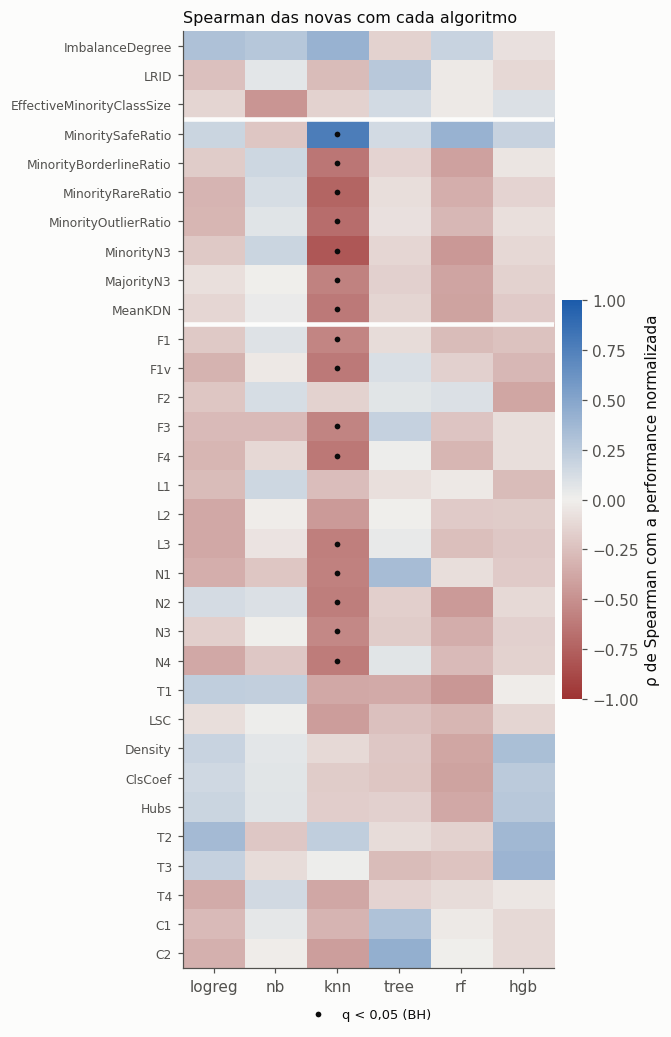

In [12]:
ordem_novas = [c for f in ORDEM_FAMILIAS for c in NOVAS if FAMILIA[c] == f]
figura, eixo = plt.subplots(figsize=(6.2, 9.5))
matriz = rho.loc[ordem_novas].to_numpy(float)
imagem = eixo.imshow(matriz, cmap=DIVERGENTE, vmin=-1, vmax=1, aspect="auto")
linhas_sig, colunas_sig = np.where(significativa.loc[ordem_novas].to_numpy())
eixo.scatter(colunas_sig, linhas_sig, s=14, color=a1.TINTA, marker="o", linewidths=0,
             label="q < 0,05 (BH)")
eixo.set_xticks(range(n_algos), ALGORITMOS)
eixo.set_yticks(range(len(ordem_novas)), ordem_novas, fontsize=8)
eixo.grid(False)
for fronteira in np.cumsum([sum(FAMILIA[c] == f for c in NOVAS) for f in ORDEM_FAMILIAS[5:]])[:-1]:
    eixo.axhline(fronteira - 0.5, color=a1.SUPERFICIE, lw=3)
barra = figura.colorbar(imagem, ax=eixo, fraction=0.05, pad=0.02)
barra.set_label("ρ de Spearman com a performance normalizada")
barra.outline.set_visible(False)
eixo.legend(loc="upper center", bbox_to_anchor=(0.5, -0.03), frameon=False, fontsize=8.5)
eixo.set_title("Spearman das novas com cada algoritmo", loc="left", fontsize=10.5)
figura.tight_layout()
plt.show()

In [13]:
X_imp = X_ext.fillna(X_ext.median())
importancia = pd.DataFrame(0.0, index=X_ext.columns, columns=ALGORITMOS)
SEMENTES_IMPORTANCIA = range(10)
for alg in ALGORITMOS:
    for semente in SEMENTES_IMPORTANCIA:
        floresta = RandomForestRegressor(n_estimators=500, min_samples_leaf=3, random_state=semente,
                                         n_jobs=-1).fit(X_imp, P_norm[alg])
        importancia[alg] += floresta.feature_importances_ / len(SEMENTES_IMPORTANCIA)

parcela = importancia.groupby(familia).sum().reindex(ORDEM_FAMILIAS)
parcela["parcela das colunas"] = familia.value_counts(normalize=True).reindex(ORDEM_FAMILIAS)
top_por_algoritmo = pd.Series({alg: ", ".join(importancia[alg].nlargest(3).index) for alg in ALGORITMOS},
                              name="3 mais importantes")

print("Quadro 8: importância por família (random forest, 10 sementes)")
display(parcela.round(3))
print("importância / parcela das colunas")
display(parcela[ALGORITMOS].div(parcela["parcela das colunas"], axis=0).round(2))
top_por_algoritmo.to_frame()

Quadro 8: importância por família (random forest, 10 sementes)


,logreg,nb,knn,tree,rf,hgb,parcela das colunas
base · gerais,0.097,0.017,0.017,0.041,0.021,0.035,0.141
base · balanceamento,0.034,0.119,0.012,0.114,0.012,0.305,0.062
base · estatísticas,0.071,0.051,0.044,0.106,0.016,0.011,0.062
base · informação,0.087,0.041,0.275,0.079,0.021,0.020,0.078
base · derivadas,0.122,0.119,0.018,0.089,0.022,0.221,0.156
domínio · desbalanceamento,0.023,0.250,0.010,0.026,0.007,0.084,0.047
domínio · vizinhança,0.042,0.082,0.270,0.086,0.190,0.023,0.109
complexidade,0.526,0.321,0.353,0.459,0.710,0.302,0.344


importância / parcela das colunas


,logreg,nb,knn,tree,rf,hgb
base · gerais,0.69,0.12,0.12,0.29,0.15,0.25
base · balanceamento,0.54,1.91,0.20,1.82,0.19,4.88
base · estatísticas,1.13,0.82,0.70,1.69,0.25,0.17
base · informação,1.11,0.52,3.52,1.01,0.27,0.25
base · derivadas,0.78,0.76,0.12,0.57,0.14,1.41
domínio · desbalanceamento,0.49,5.34,0.21,0.56,0.15,1.79
domínio · vizinhança,0.38,0.75,2.47,0.78,1.74,0.21
complexidade,1.53,0.93,1.03,1.33,2.07,0.88


,3 mais importantes
logreg,"T4, N4, F1v"
nb,"EffectiveMinorityClassSize, T1, NormalizedClas..."
knn,"NoiseToSignalRatio, MinorityN3, N2"
tree,"T4, MinorityClassSize, MeanKurtosisOfNumericAtts"
rf,"L3, N4, MinorityBorderlineRatio"
hgb,"MinorityClassSize, ClassImbalanceRatio, F1v"


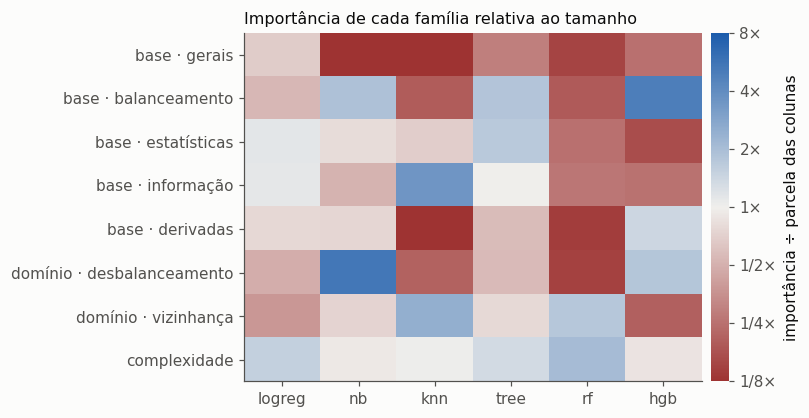

In [14]:
relativa = parcela[ALGORITMOS].div(parcela["parcela das colunas"], axis=0)
log_relativa = np.log2(relativa.clip(lower=2 ** -3))
limite = float(np.ceil(np.abs(log_relativa.to_numpy()).max()))

figura, eixo = plt.subplots(figsize=(7.4, 3.9))
imagem = eixo.imshow(log_relativa.to_numpy(), cmap=DIVERGENTE, vmin=-limite, vmax=limite, aspect="auto")
eixo.set_xticks(range(n_algos), ALGORITMOS)
eixo.set_yticks(range(len(ORDEM_FAMILIAS)), ORDEM_FAMILIAS)
eixo.grid(False)
marcas = np.arange(-limite, limite + 1)
barra = figura.colorbar(imagem, ax=eixo, fraction=0.04, pad=0.02, ticks=marcas)
barra.ax.set_yticklabels([f"{2 ** m:g}×" if m >= 0 else f"1/{2 ** -m:g}×" for m in marcas])
barra.set_label("importância ÷ parcela das colunas")
barra.outline.set_visible(False)
eixo.set_title("Importância de cada família relativa ao tamanho", loc="left", fontsize=10.5)
figura.tight_layout()
plt.show()

### 3.2 Redundância

Spearman entre as meta-características e agrupamento hierárquico (ligação completa) cortado em |ρ| = 0,9.
Uma nova é redundante se cai no mesmo grupo de alguma do X_base.

In [15]:
LIMIAR = 0.9
correlacao = X_imp.loc[:, X_imp.nunique() > 1].corr(method="spearman").abs()


def grupos_de(colunas):
    sub = correlacao.loc[colunas, colunas].to_numpy()
    arvore = linkage(squareform(1 - sub, checks=False), method="complete")
    return pd.Series(fcluster(arvore, 1 - LIMIAR, criterion="distance"), index=colunas)


variaveis = list(correlacao.index)
grupos = grupos_de(variaveis)
base_variaveis = [c for c in variaveis if c in X_base.columns]
novas_variaveis = [c for c in variaveis if c in NOVAS]

quadro_redundancia = pd.DataFrame({
    "família": [FAMILIA[c] for c in novas_variaveis],
    "clássica mais próxima": [correlacao.loc[c, base_variaveis].idxmax() for c in novas_variaveis],
    "|ρ|": [correlacao.loc[c, base_variaveis].max() for c in novas_variaveis],
    "grupo tem clássica": [any(grupos[g] == grupos[c] for g in base_variaveis) for c in novas_variaveis],
}, index=novas_variaveis).sort_values("|ρ|", ascending=False)

resumo_grupos = pd.Series({
    "colunas do X_base": X_base.shape[1],
    "grupos no X_base": grupos_de(base_variaveis).nunique(),
    "colunas do X estendido": X_ext.shape[1],
    "grupos no X estendido": grupos.nunique(),
    "novas redundantes com o X_base": int(quadro_redundancia["grupo tem clássica"].sum()),
    "novas em grupo só de novas": int((~quadro_redundancia["grupo tem clássica"]).sum()),
    "grupos criados pelas novas": grupos[novas_variaveis][~quadro_redundancia.loc[novas_variaveis,
                                                          "grupo tem clássica"].to_numpy()].nunique(),
    "colunas constantes (fora)": int((X_imp.nunique() <= 1).sum()),
}, name="valor")

print("Quadro 9: clássica mais correlacionada com cada nova")
display(quadro_redundancia.round(3))
print("Quadro 10: grupos com |ρ| ≥ 0,9")
resumo_grupos.to_frame()

Quadro 9: clássica mais correlacionada com cada nova


,família,clássica mais próxima,|ρ|,grupo tem clássica
C2,complexidade,MajorityClassPercentage,0.999,True
C1,complexidade,NormalizedClassEntropy,0.998,True
LRID,domínio · desbalanceamento,NormalizedClassEntropy,0.982,True
EffectiveMinorityClassSize,domínio · desbalanceamento,MinorityClassPercentage,0.930,True
T2,complexidade,NumberOfFeatures,0.910,True
N1,complexidade,NumberOfClasses,0.859,False
ImbalanceDegree,domínio · desbalanceamento,MinorityClassPercentage,0.806,False
T3,complexidade,NumberOfFeatures,0.752,False
MinorityBorderlineRatio,domínio · vizinhança,NoiseToSignalRatio,0.741,False
MinorityN3,domínio · vizinhança,NoiseToSignalRatio,0.728,False


Quadro 10: grupos com |ρ| ≥ 0,9


,valor
colunas do X_base,32
grupos no X_base,20
colunas do X estendido,64
grupos no X estendido,41
novas redundantes com o X_base,5
novas em grupo só de novas,27
grupos criados pelas novas,21
colunas constantes (fora),0


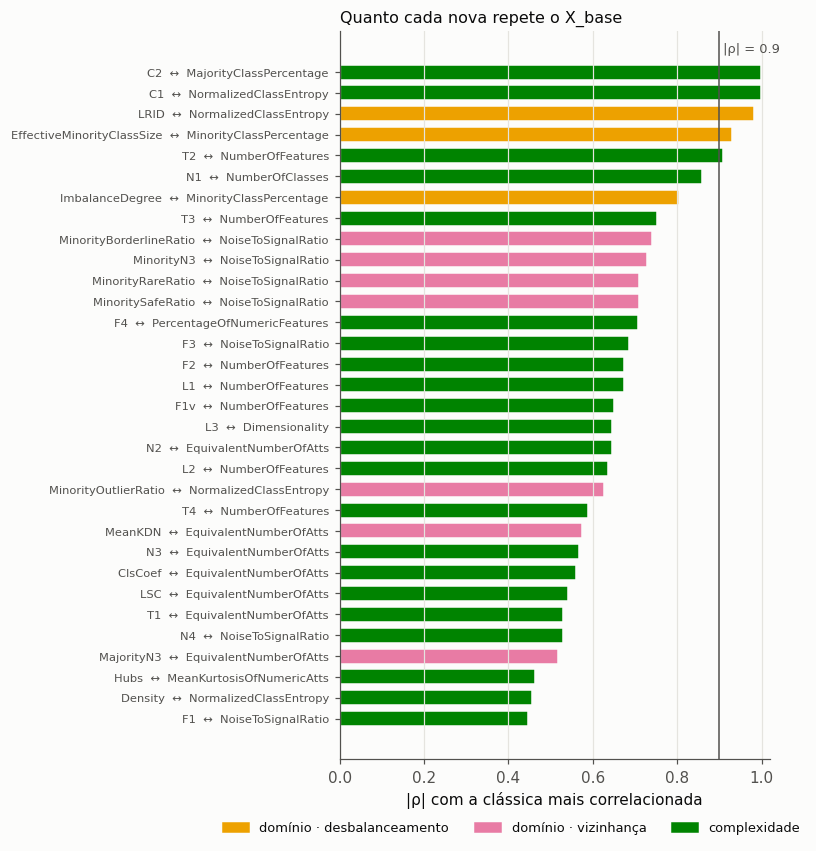

In [16]:
CORES_FAMILIA = {"domínio · desbalanceamento": a1.SERIES[3], "domínio · vizinhança": "#e87ba4",
                 "complexidade": "#008300"}
ordem = quadro_redundancia.sort_values("|ρ|")
figura, eixo = plt.subplots(figsize=(7.2, 7.8))
eixo.barh(range(len(ordem)), ordem["|ρ|"], color=[CORES_FAMILIA[f] for f in ordem["família"]],
          height=0.72, edgecolor=a1.SUPERFICIE, linewidth=1)
eixo.axvline(LIMIAR, color=a1.TINTA_2, lw=1)
eixo.text(LIMIAR, len(ordem) - 0.2, f" |ρ| = {LIMIAR}", color=a1.TINTA_2, fontsize=8.5, va="bottom")
eixo.set_yticks(range(len(ordem)), [f"{m}  ↔  {c}" for m, c in zip(ordem.index, ordem["clássica mais próxima"])],
                fontsize=7.5)
eixo.set_xlim(0, 1.02)
eixo.set_xlabel("|ρ| com a clássica mais correlacionada")
eixo.grid(axis="y", visible=False)
from matplotlib.patches import Patch
eixo.legend(handles=[Patch(color=cor, label=rotulo) for rotulo, cor in CORES_FAMILIA.items()],
            loc="upper center", bbox_to_anchor=(0.4, -0.07), ncol=3, frameon=False, fontsize=8.5)
eixo.set_title("Quanto cada nova repete o X_base", loc="left", fontsize=10.5)
figura.tight_layout()
plt.show()

X filtrado: o X_base inteiro mais as novas que não repetem nenhuma clássica (uma por grupo). A seleção é
refeita em cada rodada, só com os 32 datasets de treino.

In [17]:
def colunas_filtradas(Xtr, eh_base, limiar=LIMIAR):
    variavel = Xtr.std(axis=0) > 0
    rho_abs = np.nan_to_num(np.abs(pd.DataFrame(Xtr).corr(method="spearman").to_numpy()))
    base = np.where(eh_base)[0]
    base_variavel = base[variavel[base]]
    candidatas = [j for j in np.where(~eh_base & variavel)[0] if rho_abs[j, base_variavel].max() < limiar]
    if len(candidatas) <= 1:
        return np.r_[base, candidatas].astype(int)
    sub = rho_abs[np.ix_(candidatas, candidatas)]
    rotulos = fcluster(linkage(squareform(1 - sub, checks=False), "complete"), 1 - limiar, "distance")
    escolhidas = []
    for g in np.unique(rotulos):
        membros = [c for c, r in zip(candidatas, rotulos) if r == g]
        escolhidas.append(membros[int(np.argmax(rho_abs[np.ix_(membros, membros)].mean(axis=1)))])
    return np.r_[base, sorted(escolhidas)].astype(int)


eh_base_ext = np.array([c in X_base.columns for c in X_ext.columns])
Xn_ext = X_ext.to_numpy(float)
selecoes = []
for i in range(n_datasets):
    treino = np.delete(np.arange(n_datasets), i)
    mediana = np.nanmedian(Xn_ext[treino], axis=0)
    selecoes.append(colunas_filtradas(np.where(np.isnan(Xn_ext[treino]), mediana, Xn_ext[treino]), eh_base_ext))

vezes = pd.Series(0, index=NOVAS)
for sel in selecoes:
    vezes[[X_ext.columns[j] for j in sel if not eh_base_ext[j]]] += 1
tamanhos = [len(s) for s in selecoes]

print(f"Quadro 11: rodadas em que cada nova entrou no X filtrado ({min(tamanhos)} a {max(tamanhos)} colunas)")
vezes[vezes > 0].sort_values(ascending=False).rename("rodadas").to_frame().assign(
    família=lambda q: [FAMILIA[c] for c in q.index])

Quadro 11: rodadas em que cada nova entrou no X filtrado (52 a 53 colunas)


,rodadas,família
ImbalanceDegree,33,domínio · desbalanceamento
MinorityBorderlineRatio,33,domínio · vizinhança
MeanKDN,33,domínio · vizinhança
F3,33,complexidade
F2,33,complexidade
F1v,33,complexidade
F1,33,complexidade
Density,33,complexidade
N4,33,complexidade
T1,33,complexidade


### 3.3 Efeito no sistema de recomendação

Regressor sobre P, regressor sobre R e HARRIS (λ = 0,5) com cinco versões de X, no mesmo
leave-one-dataset-out da Atividade 1. O AR fica de referência: não usa X (MR e VS dão o mesmo resultado).

In [18]:
colunas_dominio = [c for c in NOVAS if FAMILIA[c].startswith("domínio")]
VARIANTES = {
    "base": X_base,
    "base + domínio": X_base.join(mf_novas[colunas_dominio]),
    "base + complexidade": X_base.join(mf_novas[list(MEDIDAS)]),
    "estendido": X_ext,
    "filtrado": X_ext,
}
ABORDAGENS = {"reg-P": a1.reg_p, "reg-R": a1.reg_r, "HARRIS": partial(a1.harris, lam=a1.LAMBDA_DC)}
CAMINHO_PREV = Path("previsoes_x.csv")


def rodadas(Xdf, filtrar=False):
    Xn = Xdf.to_numpy(float)
    eh_base = np.array([c in X_base.columns for c in Xdf.columns])
    saida = []
    for i in range(n_datasets):
        treino = np.delete(np.arange(n_datasets), i)
        mediana = np.nanmedian(Xn[treino], axis=0)
        Xtr = np.where(np.isnan(Xn[treino]), mediana, Xn[treino])
        xte = np.where(np.isnan(Xn[i]), mediana, Xn[i])
        colunas = colunas_filtradas(Xtr, eh_base) if filtrar else np.arange(Xn.shape[1])
        saida.append(a1.Rodada(Xtr[:, colunas], Pn[treino], Rn[treino], Vn[treino], xte[colunas]))
    return saida


feitas = set()
if CAMINHO_PREV.exists():
    feitas = set(map(tuple, pd.read_csv(CAMINHO_PREV)[["variante", "abordagem"]].drop_duplicates().to_numpy()))

tarefas = [("base", "AR", a1.ar)] + [(v, a, f) for v in VARIANTES for a, f in ABORDAGENS.items()]
for variante, abordagem, funcao in tarefas:
    if (variante, abordagem) in feitas:
        continue
    inicio = time.perf_counter()
    previstos = [funcao(d) for d in rodadas(VARIANTES[variante], filtrar=variante == "filtrado")]
    _anexar(CAMINHO_PREV, [{"variante": variante, "abordagem": abordagem, "did": did, "nome": nome,
                            **dict(zip(ALGORITMOS, g))} for (did, nome), g in zip(P.index, previstos)])
    print(f"{abordagem:<7} {variante:<20} {time.perf_counter() - inicio:6.1f}s")

previsoes = pd.read_csv(CAMINHO_PREV)


def matriz(variante, abordagem):
    g = previsoes[(previsoes.variante == variante) & (previsoes.abordagem == abordagem)]
    return g.set_index("did").loc[P.index.get_level_values("did"), ALGORITMOS].to_numpy()


atividade1_prev = pd.read_csv(BASE / "previsoes.csv")
reproduz = {a: np.array_equal(matriz("base", a),
                              atividade1_prev[atividade1_prev.abordagem == nome_a1].sort_values("did")[ALGORITMOS].to_numpy())
            for a, nome_a1 in (("AR", "AR"), ("reg-P", "reg-P"), ("reg-R", "reg-R"), ("HARRIS", "HARRIS λ=0.50"))}
assert all(reproduz.values()), reproduz
print("base igual à Atividade 1:", reproduz)

base igual à Atividade 1: {'AR': True, 'reg-P': True, 'reg-R': True, 'HARRIS': True}


In [19]:
def avaliar(G):
    spearman = np.array([stats.spearmanr(G[i], Rn[i]).statistic for i in range(n_datasets)])
    curvas = np.array([[Pn[i].max() - Pn[i][np.argsort(G[i], kind="stable")[:t]].max()
                        for t in range(1, n_algos + 1)] for i in range(n_datasets)])
    return spearman, curvas, curvas / (Pn.max(axis=1) - Pn.min(axis=1))[:, None]


resultado = {("AR", "—"): avaliar(matriz("base", "AR"))}
for abordagem in ABORDAGENS:
    for variante in VARIANTES:
        resultado[(abordagem, variante)] = avaliar(matriz(variante, abordagem))

quadro_metricas = pd.DataFrame.from_dict({
    chave: {"colunas": ("—" if chave[0] == "AR" else
                        f"{min(tamanhos)}–{max(tamanhos)}" if chave[1] == "filtrado"
                        else str(VARIANTES[chave[1]].shape[1])),
            "spearman": sp.mean(), "perda@1": cv[:, 0].mean(), "perda@2": cv[:, 1].mean(),
            "área": cv.mean(), "área norm.": cn.mean()}
    for chave, (sp, cv, cn) in resultado.items()}, orient="index")
quadro_metricas.index = pd.MultiIndex.from_tuples(quadro_metricas.index, names=["abordagem", "X"])
print("Quadro 12: métricas por abordagem e versão de X")
quadro_metricas.round(4)

Quadro 12: métricas por abordagem e versão de X


colunas  spearman  perda@1  perda@2    área  \
abordagem X                                                                 
AR        —                         —    0.7796   0.0172   0.0022  0.0033   
reg-P     base                     32    0.7446   0.0053   0.0022  0.0013   
          base + domínio           42    0.7242   0.0085   0.0023  0.0018   
          base + complexidade      54    0.7475   0.0067   0.0025  0.0016   
          estendido                64    0.7311   0.0077   0.0023  0.0017   
          filtrado              52–53    0.7380   0.0084   0.0022  0.0018   
reg-R     base                     32    0.7928   0.0039   0.0022  0.0013   
          base + domínio           42    0.8076   0.0038   0.0022  0.0010   
          base + complexidade      54    0.7962   0.0061   0.0022  0.0014   
          estendido                64    0.8014   0.0061   0.0022  0.0014   
          filtrado              52–53    0.7996   0.0059   0.0022  0.0014   
HARRIS    base                     32    0.7895   0.0038   0.0022  0.0013   
          base + domínio           42    0.7929   0.0045   0.0022  0.0011   
          base + complexidade      54    0.7910   0.0038   0.0022  0.0013   
          estendido                64    0.8016   0.0038   0.0022  0.0010   
          filtrado              52–53    0.7911   0.0039   0.0022  0.0010   

                               área norm.  
abordagem X                                
AR        —                        0.0190  
reg-P     base                     0.0101  
          base + domínio           0.0123  
          base + complexidade      0.0107  
          estendido                0.0109  
          filtrado                 0.0113  
reg-R     base                     0.0097  
          base + domínio           0.0083  
          base + complexidade      0.0100  
          estendido                0.0100  
          filtrado                 0.0099  
HARRIS    base                     0.0096  
          base + domínio           0.0091  
          base + complexidade      0.0096  
          estendido                0.0085  
          filtrado                 0.0086

In [20]:
def pareado(melhor, pior):
    diferenca = melhor - pior
    if np.allclose(diferenca, 0):
        return 1.0
    return float(stats.wilcoxon(melhor, pior, zero_method="pratt").pvalue)


linhas = []
for abordagem in ABORDAGENS:
    sp_base, cv_base, cn_base = resultado[(abordagem, "base")]
    for variante in list(VARIANTES)[1:]:
        sp, cv, cn = resultado[(abordagem, variante)]
        area_base, area = cn_base.mean(axis=1), cn.mean(axis=1)
        linhas.append({
            "abordagem": abordagem, "X": variante,
            "Δ spearman": sp.mean() - sp_base.mean(),
            "spearman: melhora / piora / igual": f"{(sp > sp_base).sum()} / {(sp < sp_base).sum()} / {(sp == sp_base).sum()}",
            "p (spearman)": pareado(sp, sp_base),
            "Δ área norm.": area.mean() - area_base.mean(),
            "área: melhora / piora / igual": f"{(area < area_base).sum()} / {(area > area_base).sum()} / {(area == area_base).sum()}",
            "p (área)": pareado(area, area_base),
        })
quadro_pareado = pd.DataFrame(linhas).set_index(["abordagem", "X"])
print("Quadro 13: cada versão de X contra o X_base (Wilcoxon pareado)")
quadro_pareado.round(4)

Quadro 13: cada versão de X contra o X_base (Wilcoxon pareado)


Δ spearman spearman: melhora / piora / igual  \
abordagem X                                                                   
reg-P     base + domínio          -0.0204                       10 / 9 / 14   
          base + complexidade      0.0029                      10 / 11 / 12   
          estendido               -0.0135                      10 / 12 / 11   
          filtrado                -0.0067                      10 / 13 / 10   
reg-R     base + domínio           0.0148                       10 / 3 / 20   
          base + complexidade      0.0033                       13 / 6 / 14   
          estendido                0.0085                       14 / 5 / 14   
          filtrado                 0.0068                       14 / 5 / 14   
HARRIS    base + domínio           0.0035                        3 / 3 / 27   
          base + complexidade      0.0015                        4 / 4 / 25   
          estendido                0.0122                        5 / 2 / 26   
          filtrado                 0.0017                        3 / 3 / 27   

                               p (spearman)  Δ área norm.  \
abordagem X                                                 
reg-P     base + domínio             0.8085        0.0022   
          base + complexidade        0.8905        0.0006   
          estendido                  0.5968        0.0007   
          filtrado                   0.6177        0.0012   
reg-R     base + domínio             0.0766       -0.0014   
          base + complexidade        0.2184        0.0004   
          estendido                  0.0971        0.0004   
          filtrado                   0.1048        0.0002   
HARRIS    base + domínio             1.0000       -0.0006   
          base + complexidade        0.9428       -0.0000   
          estendido                  0.2686       -0.0011   
          filtrado                   0.9893       -0.0011   

                              área: melhora / piora / igual  p (área)  
abordagem X                                                            
reg-P     base + domínio                        3 / 10 / 20    0.0626  
          base + complexidade                    5 / 7 / 21    0.5050  
          estendido                             6 / 10 / 17    0.3748  
          filtrado                               4 / 8 / 21    0.2606  
reg-R     base + domínio                         4 / 1 / 28    0.1802  
          base + complexidade                    3 / 1 / 29    0.3412  
          estendido                              4 / 1 / 28    0.1996  
          filtrado                               3 / 1 / 29    0.3412  
HARRIS    base + domínio                         2 / 2 / 29    1.0000  
          base + complexidade                    1 / 0 / 32    0.3173  
          estendido                              2 / 1 / 30    0.5638  
          filtrado                               2 / 1 / 30    0.5638

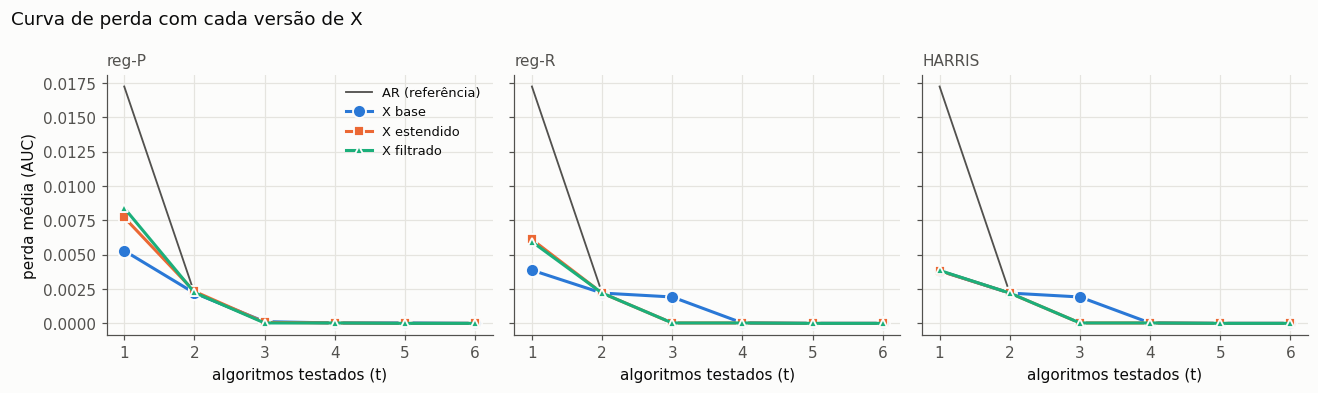

In [21]:
MOSTRAR = {"base": a1.SERIES[0], "estendido": a1.SERIES[1], "filtrado": a1.SERIES[2]}
MARCADORES = {"base": "o", "estendido": "s", "filtrado": "^"}
t = np.arange(1, n_algos + 1)
figura, eixos = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for eixo, abordagem in zip(eixos, ABORDAGENS):
    eixo.plot(t, resultado[("AR", "—")][1].mean(axis=0), color=a1.TINTA_2, lw=1.2, label="AR (referência)")
    for (variante, cor), tamanho in zip(MOSTRAR.items(), (8.5, 7, 5.5)):
        eixo.plot(t, resultado[(abordagem, variante)][1].mean(axis=0), color=cor, lw=2, marker=MARCADORES[variante],
                  ms=tamanho, markeredgecolor=a1.SUPERFICIE, markeredgewidth=1.2, label=f"X {variante}")
    eixo.set_title(abordagem, loc="left", fontsize=10, color=a1.TINTA_2)
    eixo.set_xticks(t)
    eixo.set_xlabel("algoritmos testados (t)")
eixos[0].set_ylabel("perda média (AUC)")
eixos[0].legend(frameon=False, fontsize=8.5)
figura.suptitle("Curva de perda com cada versão de X", x=0.005, ha="left", fontsize=12)
figura.tight_layout()
plt.show()

Friedman: χ² = 35.91, p = 2.87e-06 | Nemenyi: k = 7, N = 33, CD = 1.568
reg-R · estendido     3.091
HARRIS · estendido    3.515
AR                    3.697
reg-R · base          3.864
HARRIS · base         3.879
reg-P · base          4.803
reg-P · estendido     5.152


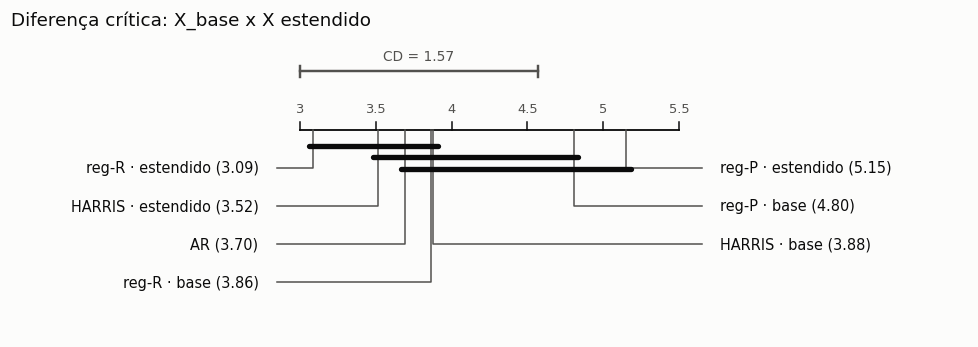

In [22]:
ENTRADAS_DC = [("AR", "—")] + [(a, v) for a in ABORDAGENS for v in ("base", "estendido")]
scores = np.column_stack([resultado[e][0] for e in ENTRADAS_DC])
estatistica, p_friedman = stats.friedmanchisquare(*scores.T)
ranks_medios = pd.Series(np.array([a1._ranquear(-linha) for linha in scores]).mean(axis=0),
                         index=[a if v == "—" else f"{a} · {v}" for a, v in ENTRADAS_DC])
k = len(ENTRADAS_DC)
cd = a1.Q_NEMENYI[k] * np.sqrt(k * (k + 1) / (6 * n_datasets))

print(f"Friedman: χ² = {estatistica:.2f}, p = {p_friedman:.3g} | Nemenyi: k = {k}, N = {n_datasets}, CD = {cd:.3f}")
print(ranks_medios.sort_values().round(3).to_string())
a1.diagrama_dc(ranks_medios, cd, "Diferença crítica: X_base x X estendido")
plt.show()

## 4. Evidência para a interpretação

In [23]:
colunas_raridade = ["EffectiveMinorityClassSize", "MinorityClassSize", "NumberOfClasses", "MajorityClassPercentage",
                    "MinoritySafeRatio", "MinorityOutlierRatio", "ImbalanceDegree"]
tabela = X_ext[colunas_raridade].copy()
tabela["MinorityClassSize"] = np.log2(tabela["MinorityClassSize"])
tabela = tabela.rename(columns={"MinorityClassSize": "log2 MinorityClassSize"})
tabela.insert(0, "rank do hgb", R["hgb"])
tabela.insert(1, "perf. norm. do hgb", P_norm["hgb"])
colapso = P_norm["hgb"] < 0.5

quadro_hgb = pd.concat([tabela[colapso].sort_values("perf. norm. do hgb"),
                        tabela[~colapso].median().to_frame("mediana dos demais").T])
associacao = pd.Series({c: stats.spearmanr(X_ext[c], P_norm["hgb"]).statistic
                        for c in ["EffectiveMinorityClassSize", "MinorityClassSize"]}, name="ρ com a perf. do hgb")

print("Quadro 14: datasets em que o hgb colapsa, contra a mediana dos outros")
display(quadro_hgb.round(3))
display(associacao.round(3).to_frame())
ordem_efetiva = tabela.sort_values("EffectiveMinorityClassSize")[["EffectiveMinorityClassSize", "rank do hgb"]].head(6)
print("6 menores classes efetivas:")
ordem_efetiva.round(2)

Quadro 14: datasets em que o hgb colapsa, contra a mediana dos outros


,rank do hgb,perf. norm. do hgb,EffectiveMinorityClassSize,log2 MinorityClassSize,NumberOfClasses,MajorityClassPercentage,MinoritySafeRatio,MinorityOutlierRatio,ImbalanceDegree
"(30, page-blocks)",5.5,0.0,4.807,4.807,5.0,89.768,0.661,0.095,3.753
"(40685, shuttle)",6.0,0.0,4.858,3.322,7.0,78.597,0.987,0.002,2.655
mediana dos demais,1.5,1.0,10.192,10.746,3.0,50.517,0.560,0.043,0.566


,ρ com a perf. do hgb
EffectiveMinorityClassSize,0.100
MinorityClassSize,0.323


6 menores classes efetivas:


,,EffectiveMinorityClassSize,rank do hgb
did,nome,,
183,abalone,3.81,4.5
30,page-blocks,4.81,5.5
40685,shuttle,4.86,6.0
41138,APSFailure,7.50,1.0
41168,jannis,7.65,1.0
300,isolet,8.22,1.5


Diagnóstico do hgb. Os testes rodam com uma thread (`threadpoolctl`), porque com várias o hgb não é
reprodutível nesses datasets (Quadro 17).

In [24]:
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from threadpoolctl import threadpool_limits

MENOR_CLASSE_EFETIVA = X_ext["EffectiveMinorityClassSize"].nsmallest(3).index.get_level_values("did").tolist()


def _dados_protocolo(did, sem_menor=False):
    df = pd.read_parquet(next(DADOS.glob(f"{did}_*.parquet")))
    Xd, yd = a1._preparar(df.drop(columns="target"), df["target"])
    yd = yd.astype(str)
    if sem_menor:
        manter = (yd != yd.value_counts().idxmin()).to_numpy()
        Xd, yd = Xd[manter].reset_index(drop=True), yd[manter].reset_index(drop=True)
    return Xd, yd


def _validar(Xd, yd, modelo):
    aucs, prob, classes = [], None, None
    for treino, teste in StratifiedKFold(a1.N_FOLDS, shuffle=True, random_state=a1.SEMENTE).split(Xd, yd):
        m = Pipeline([("pre", a1._preprocessador(Xd)), ("clf", clone(modelo))]).fit(Xd.iloc[treino], yd.iloc[treino])
        p = m.predict_proba(Xd.iloc[teste])
        if prob is None:
            classes, prob = m.classes_, np.zeros((len(yd), len(m.classes_)))
        prob[teste] = p
        aucs.append(a1._auc(yd.iloc[teste], p, m.classes_))
    return float(np.mean(aucs)), prob, classes


linhas = []
with threadpool_limits(limits=1, user_api="openmp"):
    for did in MENOR_CLASSE_EFETIVA:
        Xd, yd = _dados_protocolo(did)
        contagem = yd.value_counts()
        for chave in ("hgb", "rf"):
            _, prob, classes = _validar(Xd, yd, a1.ALGORITMOS[chave])
            por_classe = pd.Series({c: roc_auc_score(yd == c, prob[:, k]) for k, c in enumerate(classes)})
            tamanho = contagem.reindex(por_classe.index).sort_values()
            linhas.append({"dataset": P.xs(did, level="did").index[0], "algoritmo": chave,
                           "menor classe (n)": int(tamanho.iloc[0]),
                           "AUC da menor classe": por_classe[tamanho.index[0]],
                           "AUC mediana das classes": por_classe.median(),
                           "AUC da maior classe": por_classe[tamanho.index[-1]]})
quadro_por_classe = pd.DataFrame(linhas).set_index(["dataset", "algoritmo"])

print("Quadro 15: AUC por classe (fora-do-fold), hgb e rf")
quadro_por_classe.round(3)

Quadro 15: AUC por classe (fora-do-fold), hgb e rf


menor classe (n)  AUC da menor classe  \
dataset     algoritmo                                          
abalone     hgb                      14                0.646   
            rf                       14                0.725   
page-blocks hgb                      28                0.730   
            rf                       28                1.000   
shuttle     hgb                      29                0.491   
            rf                       29                1.000   

                       AUC mediana das classes  AUC da maior classe  
dataset     algoritmo                                                
abalone     hgb                          0.641                0.582  
            rf                           0.748                0.689  
page-blocks hgb                          0.730                0.770  
            rf                           0.989                0.989  
shuttle     hgb                          0.789                0.829  
            rf                           1.000                1.000

In [25]:
CONFIGURACOES = {
    "hgb padrão": (a1.ALGORITMOS["hgb"], False),
    "hgb sem a menor classe": (a1.ALGORITMOS["hgb"], True),
    "hgb, l2_regularization = 1": (HistGradientBoostingClassifier(l2_regularization=1.0, random_state=a1.SEMENTE), False),
    "hgb, min_samples_leaf = 1": (HistGradientBoostingClassifier(min_samples_leaf=1, random_state=a1.SEMENTE), False),
    "rf padrão": (a1.ALGORITMOS["rf"], False),
}
COLAPSOS = P.index[colapso.to_numpy()].get_level_values("did").tolist()
with threadpool_limits(limits=1, user_api="openmp"):
    quadro_causal = pd.DataFrame({
        P.xs(did, level="did").index[0]: {rotulo: _validar(*_dados_protocolo(did, sem_menor), modelo)[0]
                                          for rotulo, (modelo, sem_menor) in CONFIGURACOES.items()}
        for did in COLAPSOS})

print("Quadro 16: AUC macro nos datasets em que o hgb colapsa")
quadro_causal.round(4)

Quadro 16: AUC macro nos datasets em que o hgb colapsa


,page-blocks,shuttle
hgb padrão,0.8226,0.7247
hgb sem a menor classe,0.9913,1.0000
"hgb, l2_regularization = 1",0.9941,1.0000
"hgb, min_samples_leaf = 1",0.9925,1.0000
rf padrão,0.9886,1.0000


In [26]:
def _repetir(did, vezes=3):
    Xd, yd = _dados_protocolo(did)
    livre, uma_thread = [], []
    for treino, teste in StratifiedKFold(a1.N_FOLDS, shuffle=True, random_state=a1.SEMENTE).split(Xd, yd):
        def uma():
            m = Pipeline([("pre", a1._preprocessador(Xd)), ("clf", clone(a1.ALGORITMOS["hgb"]))])
            m.fit(Xd.iloc[treino], yd.iloc[treino])
            return a1._auc(yd.iloc[teste], m.predict_proba(Xd.iloc[teste]), m.classes_)
        livre.append([uma() for _ in range(vezes)])
        with threadpool_limits(limits=1, user_api="openmp"):
            uma_thread.append([uma() for _ in range(vezes)])
    amp_livre, amp_uma = np.ptp(livre, axis=1), np.ptp(uma_thread, axis=1)
    return {"folds que mudam": int((amp_livre > 1e-9).sum()),
            "amplitude máx.": amp_livre.max(),
            "amplitude máx. (1 thread)": amp_uma.max()}


quadro_determinismo = pd.DataFrame({P.xs(did, level="did").index[0]: _repetir(did)
                                    for did in COLAPSOS + [1489, 6]}).T
print("Quadro 17: 3 treinos idênticos do hgb por fold, com várias threads e com 1 thread")
quadro_determinismo.round(4)

Quadro 17: 3 treinos idênticos do hgb por fold, com várias threads e com 1 thread


,folds que mudam,amplitude máx.,amplitude máx. (1 thread)
page-blocks,5.0,0.1355,0.0
shuttle,10.0,0.2471,0.0
phoneme,0.0,0.0000,0.0
letter,0.0,0.0000,0.0


In [27]:
def _maior_escore(did, modelo):
    Xd, yd = _dados_protocolo(did)
    maior = 0.0
    for treino, teste in StratifiedKFold(a1.N_FOLDS, shuffle=True, random_state=a1.SEMENTE).split(Xd, yd):
        m = Pipeline([("pre", a1._preprocessador(Xd)), ("clf", clone(modelo))]).fit(Xd.iloc[treino], yd.iloc[treino])
        maior = max(maior, float(np.abs(m.decision_function(Xd.iloc[teste])).max()))
    return maior


with threadpool_limits(limits=1, user_api="openmp"):
    quadro_escores = pd.DataFrame({
        P.xs(did, level="did").index[0]: {
            "hgb padrão": _maior_escore(did, a1.ALGORITMOS["hgb"]),
            "hgb, l2_regularization = 1": _maior_escore(
                did, HistGradientBoostingClassifier(l2_regularization=1.0, random_state=a1.SEMENTE))}
        for did in COLAPSOS + [1489, 6]}).T

print("Quadro 18: maior |escore bruto| do hgb antes do softmax")
quadro_escores.round(1)

Quadro 18: maior |escore bruto| do hgb antes do softmax


,hgb padrão,"hgb, l2_regularization = 1"
page-blocks,95850.5,8.8
shuttle,218483.1,7.9
phoneme,9.2,8.2
letter,13.2,9.4


In [28]:
nivel = P.mean(axis=1)
media_geral = Pn.mean()
parcela_nivel = n_algos * ((nivel.to_numpy() - media_geral) ** 2).sum() / ((Pn - media_geral) ** 2).sum()

ligacao = pd.DataFrame({
    "|ρ| com o nível de AUC do dataset": {c: abs(stats.spearmanr(X_ext[c], nivel, nan_policy="omit").statistic)
                                         for c in X_ext.columns},
    "máx |ρ| com a ordem entre algoritmos": rho.abs().max(axis=1),
})
quadro_nivel = ligacao.groupby(familia).median().reindex(ORDEM_FAMILIAS)

print(f"Quadro 19: nível x ordem ({100 * parcela_nivel:.1f}% da variância de P está entre datasets)")
display(quadro_nivel.round(3))
ligacao.loc[NOVAS].sort_values("|ρ| com o nível de AUC do dataset", ascending=False).head(6).round(3)

Quadro 19: nível x ordem (71.8% da variância de P está entre datasets)


,|ρ| com o nível de AUC do dataset,máx |ρ| com a ordem entre algoritmos
base · gerais,0.267,0.321
base · balanceamento,0.393,0.399
base · estatísticas,0.017,0.231
base · informação,0.501,0.592
base · derivadas,0.267,0.297
domínio · desbalanceamento,0.278,0.413
domínio · vizinhança,0.791,0.685
complexidade,0.485,0.442


,|ρ| com o nível de AUC do dataset,máx |ρ| com a ordem entre algoritmos
MinorityRareRatio,0.881,0.732
MinorityN3,0.866,0.800
MinoritySafeRatio,0.859,0.772
MinorityOutlierRatio,0.791,0.685
N4,0.754,0.607
F1,0.745,0.559


In [29]:
subamostrado = (custo["n"] >= 9900).to_numpy()
quadro_raridade = pd.Series({
    f"subamostrados para 10 mil ({int(subamostrado.sum())})":
        stats.spearmanr(X_ext["EffectiveMinorityClassSize"][subamostrado],
                        X_ext["MinorityClassPercentage"][subamostrado]).statistic,
    f"com menos de 10 mil instâncias ({int((~subamostrado).sum())})":
        stats.spearmanr(X_ext["EffectiveMinorityClassSize"][~subamostrado],
                        X_ext["MinorityClassPercentage"][~subamostrado]).statistic,
}, name="ρ(EffectiveMinorityClassSize, MinorityClassPercentage)")

print("Quadro 20: raridade absoluta x relativa")
quadro_raridade.round(4).to_frame()

Quadro 20: raridade absoluta x relativa


,"ρ(EffectiveMinorityClassSize, MinorityClassPercentage)"
subamostrados para 10 mil (20),1.0000
com menos de 10 mil instâncias (13),0.9835


In [30]:
def primeiro(variante, abordagem):
    return pd.Series(np.array(ALGORITMOS)[matriz(variante, abordagem).argmin(axis=1)], index=P.index)


melhor_real = P.idxmax(axis=1)
linhas = []
for abordagem in ABORDAGENS:
    base_1, ext_1 = primeiro("base", abordagem), primeiro("estendido", abordagem)
    mudou = base_1 != ext_1
    for (did, nome) in P.index[mudou]:
        i = P.index.get_loc((did, nome))
        linhas.append({"abordagem": abordagem, "dataset": nome, "1º com X_base": base_1[(did, nome)],
                       "1º com X estendido": ext_1[(did, nome)], "melhor real": melhor_real[(did, nome)],
                       "perda@1 base": resultado[(abordagem, "base")][1][i, 0],
                       "perda@1 estendido": resultado[(abordagem, "estendido")][1][i, 0]})
quadro_mudancas = pd.DataFrame(linhas, columns=["abordagem", "dataset", "1º com X_base", "1º com X estendido",
                                                "melhor real", "perda@1 base", "perda@1 estendido"])
resumo_mudancas = quadro_mudancas.groupby("abordagem").agg(
    datasets=("dataset", "size"),
    **{"acertos com base": ("1º com X_base", lambda s: int((s == quadro_mudancas.loc[s.index, "melhor real"]).sum())),
       "acertos com estendido": ("1º com X estendido",
                                 lambda s: int((s == quadro_mudancas.loc[s.index, "melhor real"]).sum())),
       "perda@1 base (soma)": ("perda@1 base", "sum"), "perda@1 estendido (soma)": ("perda@1 estendido", "sum")})

print("Quadro 21: datasets em que o X estendido muda a primeira recomendação")
display(resumo_mudancas.round(4))
quadro_mudancas.round(4)

Quadro 21: datasets em que o X estendido muda a primeira recomendação


,datasets,acertos com base,acertos com estendido,perda@1 base (soma),perda@1 estendido (soma)
abordagem,,,,,
HARRIS,2,1,1,0.0000,0.0000
reg-P,10,5,3,0.1194,0.1994
reg-R,4,1,2,0.0007,0.0745


,abordagem,dataset,1º com X_base,1º com X estendido,melhor real,perda@1 base,perda@1 estendido
0,reg-P,abalone,rf,hgb,logreg,0.0624,0.1344
1,reg-P,jm1,rf,hgb,rf,0.0000,0.0053
2,reg-P,MagicTelescope,rf,hgb,rf,0.0000,0.0000
3,reg-P,adult,rf,hgb,hgb,0.0209,0.0000
4,reg-P,numerai28.6,hgb,rf,nb,0.0094,0.0072
5,reg-P,connect-4,hgb,rf,hgb,0.0000,0.0421
6,reg-P,churn,hgb,rf,hgb,0.0000,0.0063
7,reg-P,Fashion-MNIST,rf,hgb,hgb,0.0030,0.0000
8,reg-P,jungle_chess_2pcs_raw_endgame_complete,rf,hgb,hgb,0.0238,0.0000
9,reg-P,sylvine,hgb,rf,hgb,0.0000,0.0041


In [31]:
custo_total = quadro_custo["total (s)"]
custo_por_variante = {
    "base": custo_total["base"],
    "base + domínio": custo_total["base"] + custo_total["preparação"] + custo_total["domínio"],
    "base + complexidade": custo_total["base"] + custo_total["preparação"] + custo_total["complexidade"],
    "estendido": custo_total.sum(),
}
linhas = []
for variante, segundos in custo_por_variante.items():
    for abordagem in ABORDAGENS:
        sp, cv, cn = resultado[(abordagem, variante)]
        sp0, cv0, cn0 = resultado[(abordagem, "base")]
        linhas.append({"X": variante, "abordagem": abordagem, "custo total (s)": segundos,
                       "custo / custo do X_base": segundos / custo_total["base"],
                       "Δ spearman": sp.mean() - sp0.mean(), "Δ perda@1": cv[:, 0].mean() - cv0[:, 0].mean()})
quadro_custo_beneficio = pd.DataFrame(linhas).set_index(["X", "abordagem"])
print("Quadro 22: custo x efeito")
quadro_custo_beneficio.round(4)

Quadro 22: custo x efeito


custo total (s)  custo / custo do X_base  \
X                   abordagem                                             
base                reg-P                27.11                   1.0000   
                    reg-R                27.11                   1.0000   
                    HARRIS               27.11                   1.0000   
base + domínio      reg-P                40.09                   1.4788   
                    reg-R                40.09                   1.4788   
                    HARRIS               40.09                   1.4788   
base + complexidade reg-P               659.94                  24.3430   
                    reg-R               659.94                  24.3430   
                    HARRIS              659.94                  24.3430   
estendido           reg-P               668.02                  24.6411   
                    reg-R               668.02                  24.6411   
                    HARRIS              668.02                  24.6411   

                               Δ spearman  Δ perda@1  
X                   abordagem                         
base                reg-P          0.0000     0.0000  
                    reg-R          0.0000     0.0000  
                    HARRIS         0.0000     0.0000  
base + domínio      reg-P         -0.0204     0.0032  
                    reg-R          0.0148    -0.0001  
                    HARRIS         0.0035     0.0007  
base + complexidade reg-P          0.0029     0.0015  
                    reg-R          0.0033     0.0022  
                    HARRIS         0.0015    -0.0000  
estendido           reg-P         -0.0135     0.0024  
                    reg-R          0.0085     0.0022  
                    HARRIS         0.0122    -0.0000